# AIME for Image Data — signature visualisations
## Approximate Inverse Model Explanations (AIME)

AIME derives global and local feature importance by approximating the **inverse
operator** `A†` of a predictive model. Unlike perturbation- or sampling-based
methods, AIME computes contributions analytically, which improves stability and
removes the need for gradients.

For image models this unlocks views no forward-problem method can produce:

- **Representative estimation instances** `A† eₜ` — the *ideal input image* the
  model reconstructs for each class.
- **Local saliency** `(A† y) ⊙ x` — an analytic saliency map (no gradients, no
  perturbations).
- **Similarity field** — where class regions overlap in inverse-similarity
  space, i.e. where the model finds the decision hard.

We demonstrate on **MNIST** (clean, where the ideal-digit reconstruction is most
striking) and **CIFAR-10** (natural images).

## Setup

In [1]:
!pip install aime-xai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 1.9 MB/s eta 0:00:00


In [2]:
import sys, os
from aime_xai import AIME
import aime_xai, aime_xai.style as S
print('aime_xai', aime_xai.__version__)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

aime_xai 1.2.0


---
# Part 1 · MNIST

Load, subsample for speed, and train a simple multinomial logistic-regression black box. AIME only needs the model's `predict_proba`.

In [3]:
from tensorflow.keras.datasets import mnist
(Xtr, ytr), (Xte, yte) = mnist.load_data()

# flatten to (N, 784), scale to [0,1]
Xtr = (Xtr.reshape(len(Xtr), -1).astype('float32') / 255.0)
Xte = (Xte.reshape(len(Xte), -1).astype('float32') / 255.0)

# subsample for a quick, reproducible demo
rng = np.random.default_rng(0)
tr = rng.choice(len(Xtr), 8000, replace=False)
te = rng.choice(len(Xte), 2000, replace=False)
Xtr_s, ytr_s = Xtr[tr], ytr[tr]
Xte_s, yte_s = Xte[te], yte[te]

clf = LogisticRegression(max_iter=200, C=0.5)
clf.fit(Xtr_s, ytr_s)
print('test accuracy:', accuracy_score(yte_s, clf.predict(Xte_s)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
test accuracy: 0.914


In [4]:
# AIME inverse operator from inputs and predicted probabilities
yhat_tr = clf.predict_proba(Xtr_s)
yhat_te = clf.predict_proba(Xte_s)
digit_names = [str(d) for d in range(10)]

aime = AIME()
aime.create_explainer(Xtr_s, yhat_tr, normalize=True)
aime.A_dagger.shape  # (784 features, 10 classes)

(784, 10)

### Representative estimation instances — the *ideal digit*  *(unique to AIME)*
Each panel is `A† eₜ` reshaped to 28×28: the input the model reconstructs from a
pure prediction of that class. This is a **generative** read of the classifier
that LIME/SHAP cannot give.

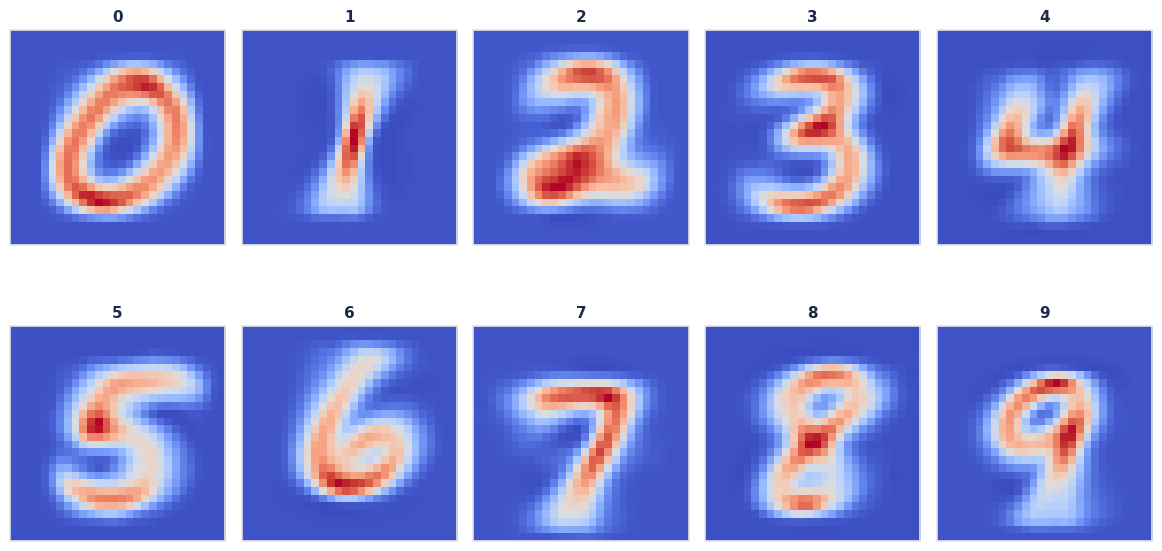

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_774,feature_775,feature_776,feature_777,feature_778,feature_779,feature_780,feature_781,feature_782,feature_783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000013,-0.000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000024,-0.000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000044,-0.000011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000049,-0.000022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000016,0.000013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000028,-0.000022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000003,-0.000003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003868,0.000165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000025,-0.000040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000259,0.001356,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
aime.plot_representative_instance(
    scaler=aime.scaler, image_shape=(28, 28),
    class_names=digit_names, ncols=5, cmap='coolwarm')

### Local saliency — why *this* image was classified  *(unique to AIME)*
The analytic saliency `(A† y) ⊙ x` reshaped to the image grid. Coral = pixels
pushing the prediction up, indigo = down.

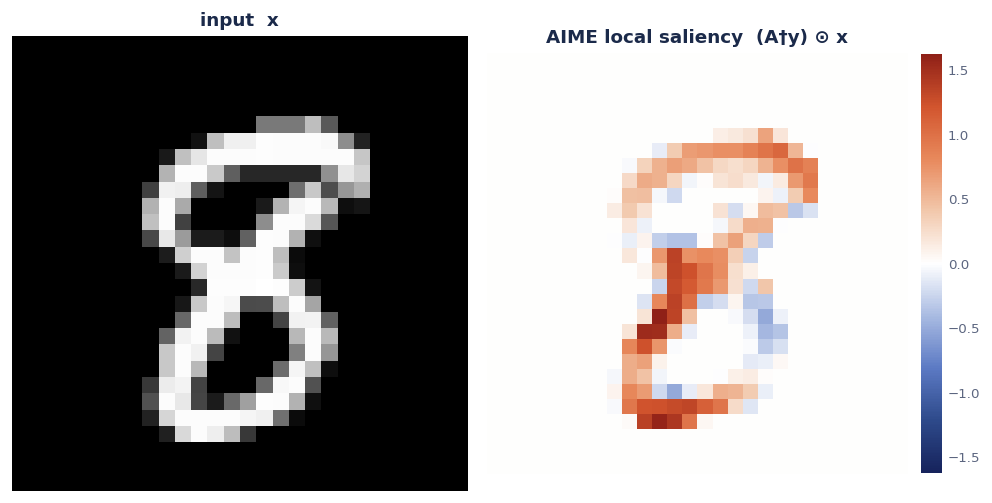

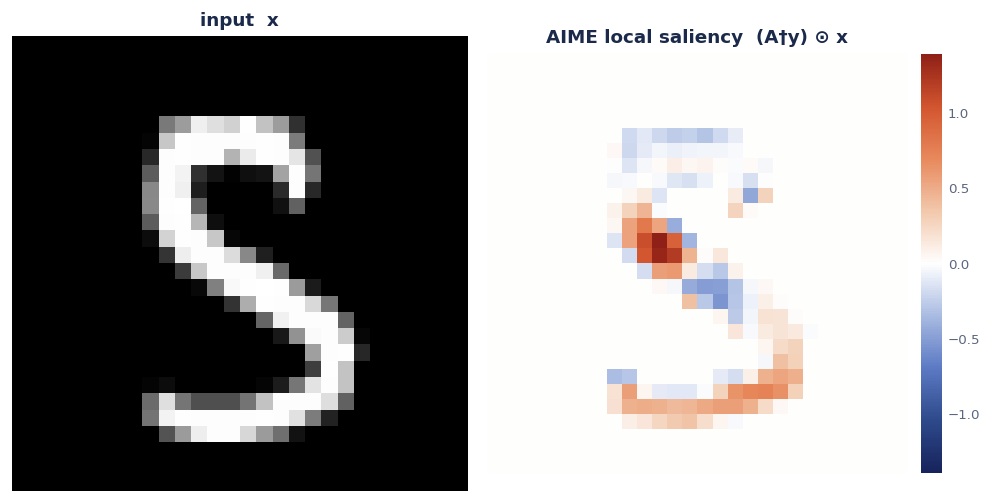

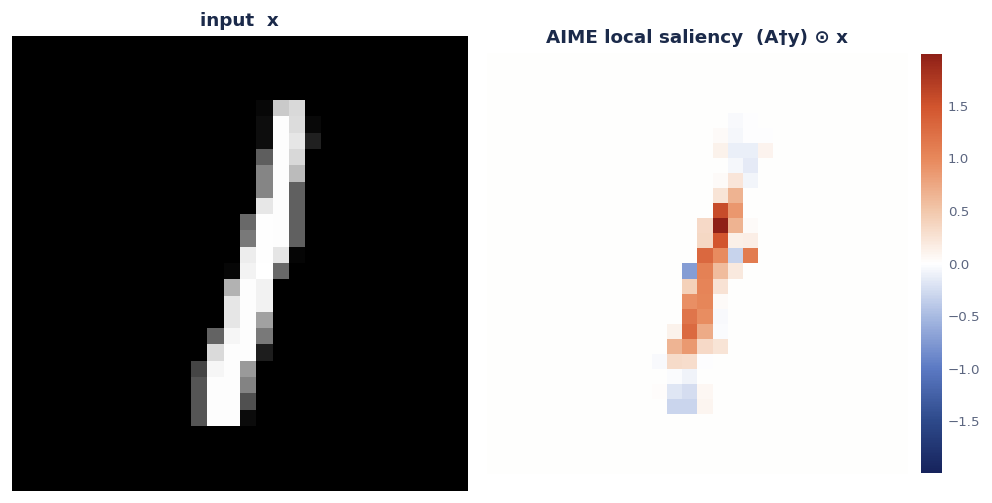

In [6]:
for idx in [0, 1, 2]:
    x = Xte_s[idx]
    y = np.eye(10)[clf.predict([x])[0]]           # one-hot of predicted class
    pred = int(np.argmax(y))
    aime.plot_local_saliency(
        x, y, image_shape=(28, 28), scaler=aime.scaler,
        title=f'MNIST · predicted {pred} (true {yte_s[idx]})')

### Interactive Inverse Reconstruction Explorer  *(uniquely AIME, renders inline in Colab)*
Drag the digit sliders to set a target output `y`; the canvas reconstructs, live,
the **ideal input image** `x = scaler⁻¹(A†·y)` the model would need to see — and
the class buttons jump to each pure representative digit. No forward-problem
method (LIME/SHAP) can do this, because it requires an explicit inverse operator.
Returned inline; pass `path=...` to also save a standalone `.html`.

In [7]:
aime.interactive_reconstruction(
    image_shape=(28, 28), class_names=digit_names,
    path='aime_mnist_reconstruction.html')

### Representative instance similarity field
Each point is scored by its RBF similarity to two classes' representative
instances; their overlap is where the model is most likely to confuse them.

**Important — choosing `gamma`.** The RBF similarity `exp(-gamma·‖·‖²)` depends
strongly on the dimensionality of the space. A `gamma` that suits a ~10-feature
tabular problem (e.g. `0.1`) makes every score underflow to ~0 in the 784-pixel
space, collapsing the plot to a line or a single point. Use **`gamma='scale'`**
(= `1/(n_features·Var(X))`, the scikit-learn convention) for image-scale inputs;
it places the scores in a readable band automatically. A numeric `gamma`
(~`1e-4` for 784-D) also works if you want manual control.

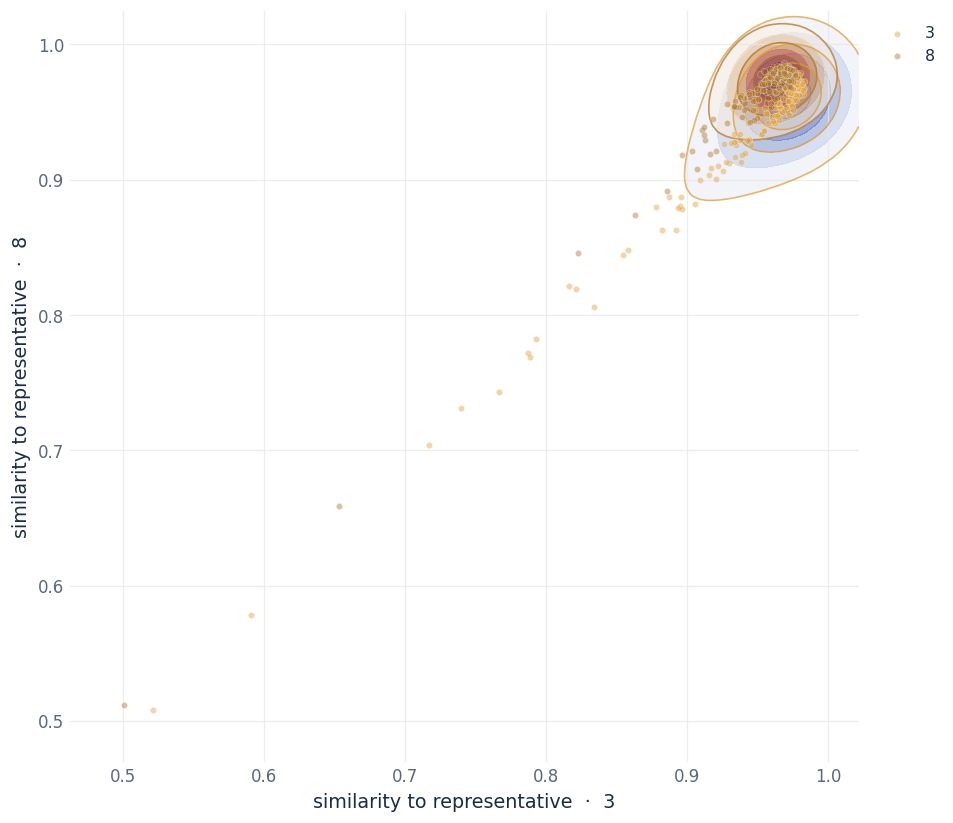

In [8]:
# compare two visually similar digits, e.g. 3 and 8
classes_to_show = [3, 8]
repdf, resdf = aime.plot_rep_instance_similarity(
    Xte_s, yhat_te, feature_names=[f'p{i}' for i in range(784)],
    class_names=digit_names, gamma='scale', scaler=aime.scaler,
    class_indices=classes_to_show)

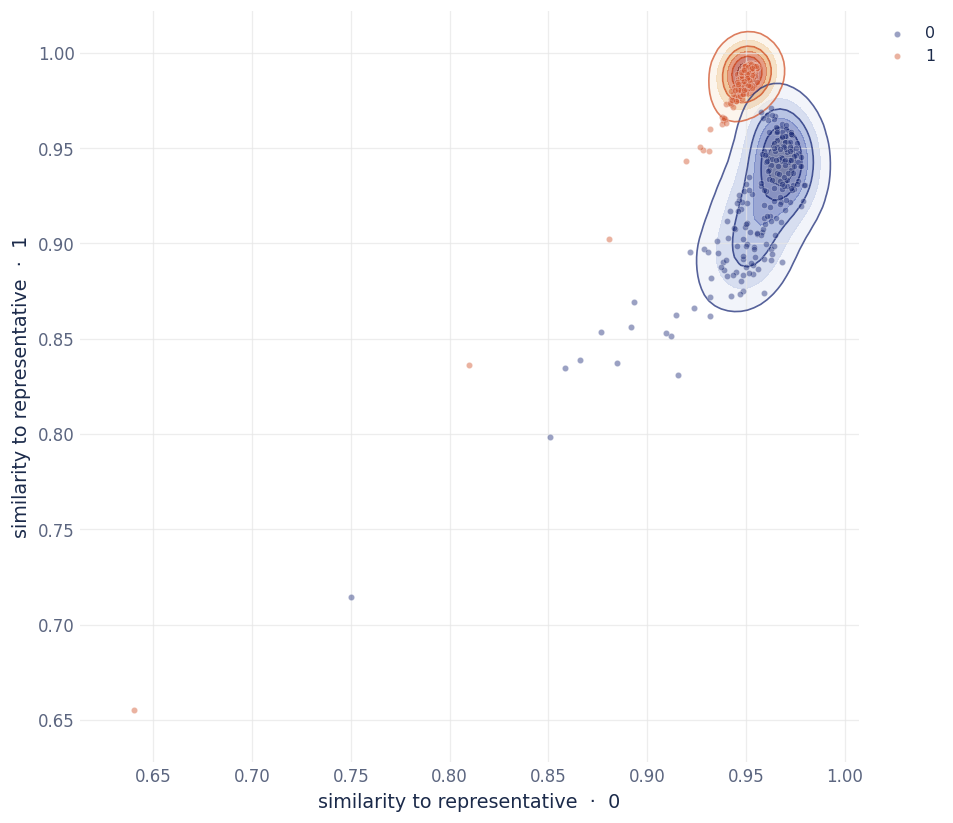

In [9]:
# compare two visually similar digits, e.g. 0 and 1
classes_to_show = [0, 1]
repdf, resdf = aime.plot_rep_instance_similarity(
    Xte_s, yhat_te, feature_names=[f'p{i}' for i in range(784)],
    class_names=digit_names, gamma='scale', scaler=aime.scaler,
    class_indices=classes_to_show)

---
# Part 2 · CIFAR-10

The same pipeline on natural colour images (32×32×3). Representative instances are necessarily more abstract than MNIST, but the inverse-operator views still apply.

In [10]:
from tensorflow.keras.datasets import cifar10
(Xc, yc), (Xct, yct) = cifar10.load_data()
yc, yct = yc.ravel(), yct.ravel()
cifar_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

Xc  = (Xc.reshape(len(Xc), -1).astype('float32') / 255.0)
Xct = (Xct.reshape(len(Xct), -1).astype('float32') / 255.0)

rng = np.random.default_rng(0)
tr = rng.choice(len(Xc), 8000, replace=False)
te = rng.choice(len(Xct), 2000, replace=False)
Xc_s, yc_s = Xc[tr], yc[tr]
Xct_s, yct_s = Xct[te], yct[te]

clf_c = LogisticRegression(max_iter=200, C=0.1)
clf_c.fit(Xc_s, yc_s)
print('CIFAR-10 test accuracy:', accuracy_score(yct_s, clf_c.predict(Xct_s)))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
CIFAR-10 test accuracy: 0.351


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
yhat_c_tr = clf_c.predict_proba(Xc_s)
aime_c = AIME()
aime_c.create_explainer(Xc_s, yhat_c_tr, normalize=True)
aime_c.A_dagger.shape  # (3072, 10)

(3072, 10)

### CIFAR-10 representative estimation instances  *(unique to AIME)*

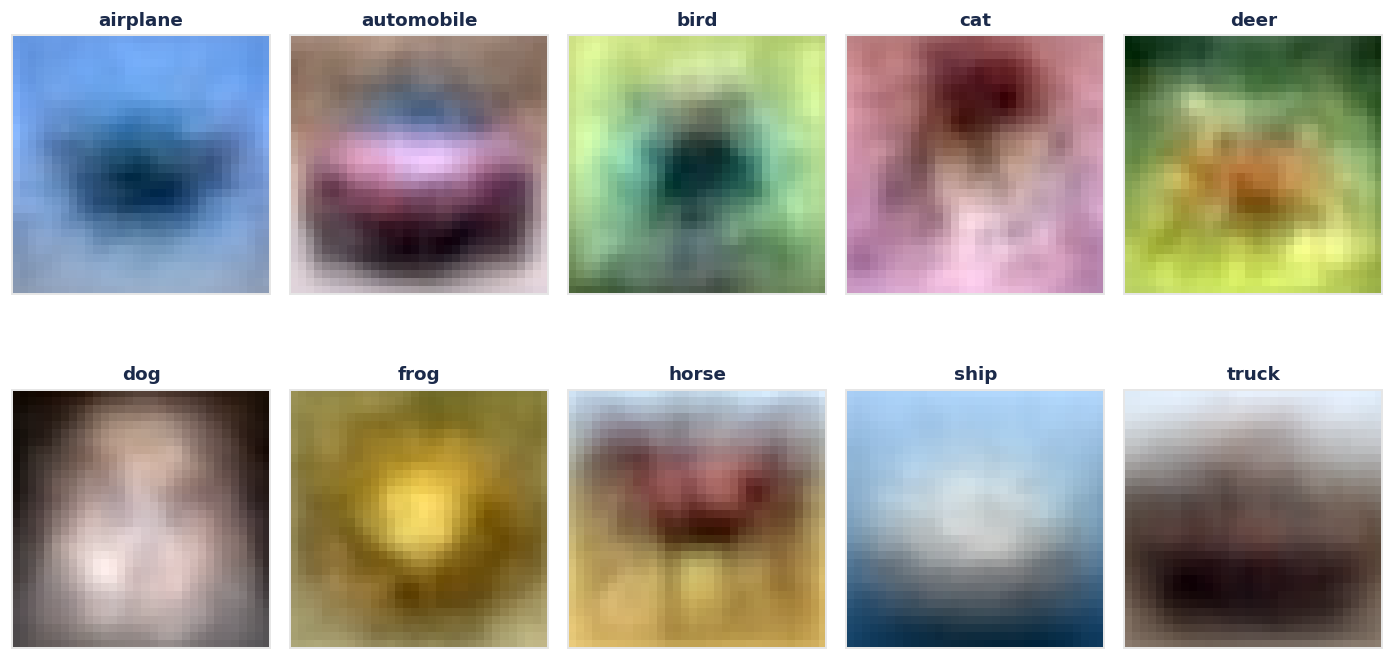

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_3062,feature_3063,feature_3064,feature_3065,feature_3066,feature_3067,feature_3068,feature_3069,feature_3070,feature_3071
airplane,0.605039,0.750836,0.968385,0.595961,0.742957,0.960992,0.599592,0.745997,0.963386,0.604231,...,0.857620,0.720295,0.766492,0.841636,0.716094,0.760509,0.832588,0.720406,0.763093,0.835453
automobile,0.477421,0.419044,0.389253,0.479430,0.420684,0.389931,0.482138,0.425886,0.394367,0.475430,...,0.577935,0.600639,0.571582,0.590091,0.610954,0.581483,0.600884,0.612478,0.582159,0.602169
bird,0.727658,0.782731,0.505302,0.748083,0.804283,0.525172,0.766336,0.825512,0.547337,0.773978,...,0.376428,0.444459,0.530187,0.388987,0.456174,0.540412,0.394902,0.442988,0.527325,0.379454
cat,0.583733,0.374402,0.387184,0.575254,0.366039,0.379908,0.564999,0.352346,0.362374,0.561729,...,0.551920,0.578587,0.401013,0.540299,0.561907,0.389142,0.533164,0.557177,0.394383,0.541534
deer,-0.004290,0.093055,0.019950,0.013126,0.110002,0.037909,0.032651,0.128335,0.055149,0.034796,...,0.213386,0.424040,0.481036,0.195986,0.408603,0.468316,0.187312,0.398637,0.457590,0.181945
dog,0.045876,0.012046,-0.015183,0.039195,0.002520,-0.024688,0.048354,0.007367,-0.020296,0.052074,...,0.372292,0.351112,0.339686,0.352693,0.334878,0.324611,0.336863,0.318105,0.306823,0.316728
frog,0.464817,0.441505,0.276329,0.448593,0.425056,0.256923,0.437659,0.412494,0.244654,0.437842,...,0.399312,0.569990,0.546044,0.413305,0.568399,0.541446,0.410168,0.571316,0.542291,0.416804
horse,0.672869,0.721613,0.766690,0.646055,0.694773,0.742023,0.637807,0.687320,0.733747,0.634952,...,0.353224,0.663272,0.574227,0.361935,0.672483,0.583899,0.373054,0.699037,0.613657,0.402009
ship,0.574793,0.704054,0.836991,0.569671,0.700305,0.832556,0.568820,0.701413,0.834244,0.572938,...,0.269210,0.030668,0.175678,0.290506,0.035348,0.183371,0.304368,0.043146,0.192445,0.316443
truck,0.964423,1.015951,1.065559,0.964013,1.016630,1.066900,0.974170,1.025762,1.076996,0.980504,...,0.504807,0.614092,0.556522,0.503534,0.619088,0.561360,0.506285,0.630789,0.573891,0.517710


In [12]:
aime_c.plot_representative_instance(
    scaler=aime_c.scaler, image_shape=(32, 32, 3),
    class_names=cifar_names, ncols=5)

### CIFAR-10 local saliency  *(unique to AIME)*
RGB saliency collapses to a signed dominant-channel magnitude per pixel.

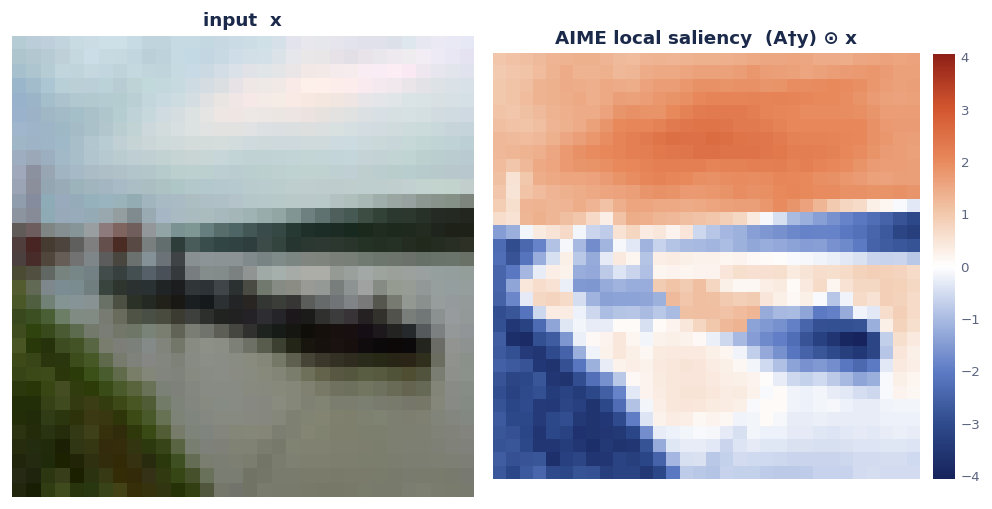

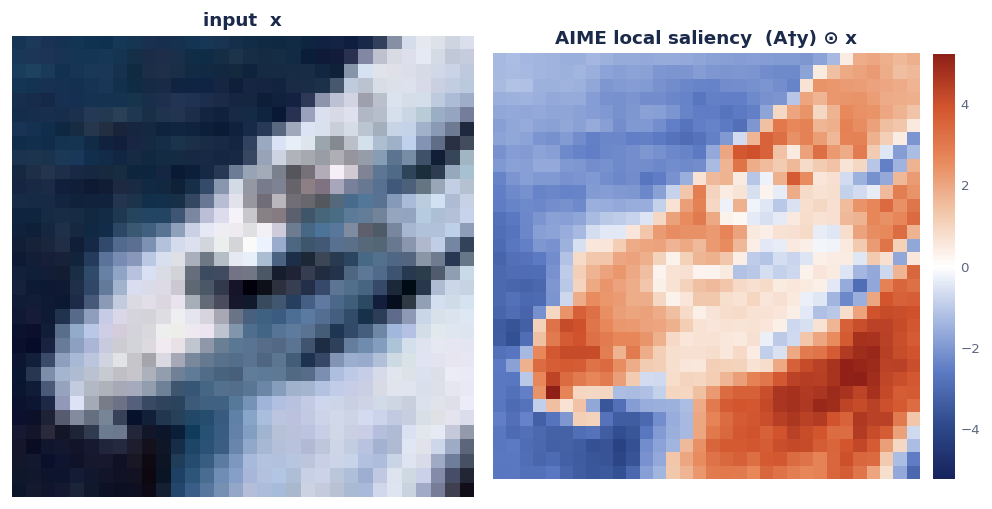

In [13]:
for idx in [0, 1]:
    x = Xct_s[idx]
    y = np.eye(10)[clf_c.predict([x])[0]]
    pred = int(np.argmax(y))
    aime_c.plot_local_saliency(
        x, y, image_shape=(32, 32, 3), scaler=aime_c.scaler,
        title=f'CIFAR-10 · predicted {cifar_names[pred]} (true {cifar_names[yct_s[idx]]})')

## Takeaways
- For image models, AIME's inverse operator yields a **generative** explanation
  (the ideal-class image) and an **analytic saliency** map — both without
  gradients or perturbations.
- On clean data (MNIST) the representative instances visibly resemble the target
  digits; on natural images (CIFAR-10) they capture coarse colour/shape priors.
- The similarity field exposes class confusion regions directly from the
  inverse-similarity geometry.

All figures carry the AIME `A†` signature look and are saved at 300 dpi when a
`save_path=` is supplied.